# Week 4 — Preprocessing & Feature Engineering
## Hands-on challenge: from messy data to model-ready data

You are given a synthetic survey dataset. Your goal is **not** a perfect dataset; it is a set of **defensible preprocessing decisions**.

We follow the same workflow as the lecture:

| Step | What | Before or after the split? |
|---|---|---|
| 1 | Inspect | before (read-only) |
| 2 | Remove duplicates, fix labels, flag impossible values | before — row-wise rules, nothing is learned |
| 3 | Choose target and features, check for target leakage | before |
| 4 | **Train / test split** | — |
| 5 | Missing values | after — medians/modes are learned from **train** |
| 6 | Outliers | after — investigate on **train** |
| 7 | Dates | after (row-wise, applied to both) |
| 8 | Engineer new features | after (row-wise, applied to both) |
| 9 | Encode categories | after — categories are learned from **train** |
| 10 | Scale numerical variables | after — mean/SD learned from **train** |
| 11 | Build a preprocessing pipeline | — |
| 12 | Leakage, revisited | — |

**Rule of thumb:** anything that *learns* from the data goes after the split; pure row-wise corrections can come before.

Run each worked example, inspect its output, and answer the short questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

df = pd.read_csv("../data/week4_messy_survey.csv")
df.head()

,respondent_id,age,gender,education,household_size,annual_income_eur,survey_date,hours_online_per_week,online_purchases_last_month,satisfaction_score,complaint_filed_after_survey
0,R0494,48.0,Male,High School,2.0,34800.0,2025-08-31,6.1,2.0,6,No
1,R0473,38.0,Non-binary,Bachelor,4.0,31000.0,2025-12-09,2.8,0.0,6,No
2,R0108,38.0,Female,Bachelor,1.0,25100.0,2025-06-15,4.3,1.0,7,No
3,R0559,26.0,Female,Bachelor,1.0,NaN,2025-10-14,4.2,0.0,9,No
4,R0536,50.0,Female,Bachelor,1.0,84800.0,2025-04-27,7.1,3.0,8,No


---
## 1. Inspect the dataset

Before changing anything, find out what you have. Inspecting the full dataset is fine — you are only *looking*, not learning parameters.

**Observe**
- How many rows and columns? What are the data types?
- Which columns contain missing values, and how many?
- Are there duplicate rows?
- What do `describe()` and `value_counts()` tell you? **Read the min and max first.**

In [17]:
# Shape and data types
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 612 non-null    object 
 1   age                           580 non-null    float64
 2   gender                        581 non-null    object 
 3   education                     588 non-null    object 
 4   household_size                594 non-null    float64
 5   annual_income_eur             565 non-null    float64
 6   survey_date                   612 non-null    object 
 7   hours_online_per_week         612 non-null    float64
 8   online_purchases_last_month   612 non-null    float64
 9   satisfaction_score            612 non-null    int64  
 10  complaint_filed_after_survey  612 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 52.7+ KB


((612, 11), None)

In [18]:
# Missing values, duplicates, summary statistics
df.isna().sum(), df.duplicated().sum(), df.describe()

(respondent_id                    0
 age                             32
 gender                          31
 education                       24
 household_size                  18
 annual_income_eur               47
 survey_date                      0
 hours_online_per_week            0
 online_purchases_last_month      0
 satisfaction_score               0
 complaint_filed_after_survey     0
 dtype: int64,
 np.int64(12),
               age  household_size  annual_income_eur  hours_online_per_week  \
 count  580.000000      594.000000         565.000000             612.000000   
 mean    47.187931        2.663300       59118.938053              14.656373   
 std     70.254614        1.396611       40871.744288               8.832388   
 min     18.000000        1.000000       -5000.000000               0.000000   
 25%     33.000000        2.000000       36200.000000               8.300000   
 50%     42.000000        2.000000       51200.000000              13.100000   
 75%     50.00

In [19]:
# Categorical counts — include missing values
df[col].value_counts(dropna=False)

annual_income_eur
NaN        47
56800.0     6
48600.0     5
40200.0     5
35600.0     5
           ..
71500.0     1
27300.0     1
63800.0     1
99000.0     1
27400.0     1
Name: count, Length: 392, dtype: int64

---
## 2. Row-wise cleaning (before the split)

These steps are **rules you decide**, not statistics learned from the data. That is why they can happen before the split.

**Tasks**
1. Remove exact duplicate rows. *Why before the split?* Otherwise a copy of the same person can land in both train and test.
2. Standardise the labels in `gender` and `education` (`"F"`, `"female"`, `" Male"`, `"MASTER"`, …).
3. Replace **impossible** values with `NaN`: which ages and incomes are impossible, not just unusual?

**Think first:** which problems can be fixed automatically, and which require a decision?

In [5]:
df_clean = df.copy().drop_duplicates()

# Standardise categorical labels with fixed, row-wise rules.
gender_map = {
    "f": "Female", "female": "Female", "m": "Male", "male": "Male",
    "non-binary": "Non-binary", "prefer not to say": "Prefer not to say",
}
education_map = {
    "high school": "High School", "bachelor": "Bachelor",
    "master": "Master", "phd": "PhD",
}

df_clean["gender"] = (
    df_clean["gender"].str.strip().str.lower().map(gender_map)
)
df_clean["education"] = (
    df_clean["education"].str.strip().str.lower().map(education_map)
)

# These values are fairly impossible rather than merely unusual. 
df_clean.loc[df_clean["age"] > 110, "age"] = np.nan
df_clean.loc[df_clean["annual_income_eur"] < 0, "annual_income_eur"] = np.nan

print("Rows after removing duplicates:", len(df_clean))
print("\nStandardised gender labels:")
print(df_clean["gender"].value_counts(dropna=False))

Rows after removing duplicates: 600

Standardised gender labels:
gender
Male                 275
Female               260
NaN                   30
Non-binary            21
Prefer not to say     14
Name: count, dtype: int64


**Checkpoint.** Run this cell. If an assertion fails, go back and fix section 2.

In [6]:
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert set(df_clean["gender"].dropna()) <= {"Female", "Male", "Non-binary", "Prefer not to say"}, "Gender labels not standardised"
assert set(df_clean["education"].dropna()) == {"High School", "Bachelor", "Master", "PhD"}, "Education labels not standardised"
assert df_clean["age"].max() <= 110, "Impossible ages remain"
assert (df_clean["annual_income_eur"].dropna() >= 0).all(), "Negative incomes remain"
print("Section 2 checks passed:", df_clean.shape)

Section 2 checks passed: (600, 11)


---
## 3. Target and features — check for target leakage

We want to predict `satisfaction_score`.

**Think:** for every column, ask *would this be available **before** we know the satisfaction score?*

- Which column only exists **because of** the outcome? That is **target leakage**: remove that column.
- Which column carries no information at all and should not be a feature?

In [7]:
target = "satisfaction_score"

# A respondent ID is only an identifier. A complaint filed after the survey
# is known too late to use when predicting satisfaction at survey time.
leaky_cols = ["complaint_filed_after_survey"]
id_cols = ["respondent_id"]

X = df_clean.drop(columns=[target] + leaky_cols + id_cols)
y = df_clean[target]
print("Features used:", X.columns.tolist())

Features used: ['age', 'gender', 'education', 'household_size', 'annual_income_eur', 'survey_date', 'hours_online_per_week', 'online_purchases_last_month']


---
## 4. Train / test split

From here on, **anything that learns from the data is fitted on `X_train` only** and then applied to `X_test`.

The test set is looked at **once, at the end**.

In [8]:
# Keep 20% of the rows aside. random_state makes this split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("train:", X_train.shape, " test:", X_test.shape)

# Sections 5-10 change Xtr/Xte. These copies keep X_train/X_test untouched
# for the all-in-one pipeline in section 11.
Xtr, Xte = X_train.copy(), X_test.copy()

train: (480, 8)  test: (120, 8)


---
## 5. Missing values

Missing ≠ zero ≠ unknown ≠ not applicable.

**Observe:** how much is missing in each column of `Xtr`? Some of these `NaN`s are values you created in section 2.

**Think:** for each column, which option fits — median, mean, most frequent, an `"Unknown"` category, or dropping rows?
- Why is the median usually safer than the mean for income?
- Why might `"Unknown"` be fine for `gender` but awkward for `education` (an ordinal variable)?

**Code:** compute the fill values **from `Xtr`**, then apply the *same* values to both `Xtr` and `Xte`.

In [9]:
# These are the columns where a median can be appropriate.
numeric_cols = [
    "age", "household_size", "annual_income_eur", "hours_online_per_week",
    "online_purchases_last_month",
]

print("Missing values in the training data:")
print(Xtr.isna().sum().sort_values(ascending=False))

# Learn one median per numeric column from TRAINING data only.
# The test set must not influence this choice.
medians = Xtr[numeric_cols].median()

# Reuse the training medians in both datasets.
Xtr[numeric_cols] = Xtr[numeric_cols].fillna(medians)
Xte[numeric_cols] = Xte[numeric_cols].fillna(medians)

# "Unknown" is a meaningful extra category for a nominal variable such as gender.
Xtr["gender"] = Xtr["gender"].fillna("Unknown")
Xte["gender"] = Xte["gender"].fillna("Unknown")

# Education is ordinal, so we use the most common TRAINING value instead.
education_mode = Xtr["education"].mode()[0]
Xtr["education"] = Xtr["education"].fillna(education_mode)
Xte["education"] = Xte["education"].fillna(education_mode)

print("\nMissing values after imputation:")
print(Xtr.isna().sum().sum(), "in train;", Xte.isna().sum().sum(), "in test")

Missing values in the training data:
annual_income_eur              40
age                            27
gender                         24
education                      19
household_size                 14
survey_date                     0
hours_online_per_week           0
online_purchases_last_month     0
dtype: int64

Missing values after imputation:
0 in train; 0 in test


---
## 6. Outliers and suspicious values

The *impossible* values were handled in section 2. What is left may be **unusual but real**.

**Observe:** use descriptive statistics and at least one plot to investigate `age` and `annual_income_eur` in `Xtr`.

**Think:** is an unusual value necessarily an error? Would you remove an income of €480,000? What would removing it do to the model — and to the people it describes?

              age  annual_income_eur
count  480.000000         480.000000
mean    41.793750       58348.541667
std     11.962762       36589.444243
min     18.000000       15200.000000
25%     34.000000       37800.000000
50%     42.000000       51200.000000
75%     49.000000       68100.000000
max     80.000000      480000.000000

Five largest incomes:
131    480000.0
149    310000.0
289    238700.0
593    180600.0
605    167800.0
Name: annual_income_eur, dtype: float64


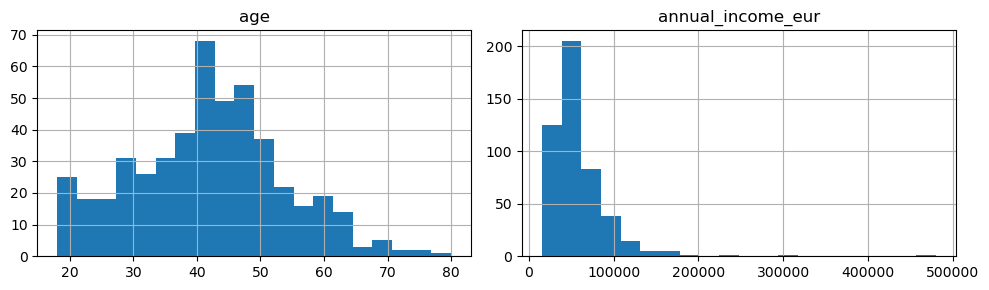

In [10]:
print(Xtr[["age", "annual_income_eur"]].describe())
print("\nFive largest incomes:")
print(Xtr["annual_income_eur"].nlargest(5))

Xtr[["age", "annual_income_eur"]].hist(bins=20, figsize=(10, 3))
plt.tight_layout()
plt.show()

# Minimal question: Based on the output, should the largest income be kept?
# It is unusual but still plausible, so we keep it.

---
## 7. Dates

`survey_date` is stored as text. Convert it to a datetime and extract at least one useful feature.

**Think:** some dates can't be parsed. What should happen to them? Is this step row-wise (no learning) or not?

In [11]:
def add_date_features(data):
    # Work on a copy so this function does not modify its input dataframe.
    result = data.copy()

    # Invalid date strings become NaT rather than causing an error.
    dates = pd.to_datetime(result["survey_date"], errors="coerce")

    # A date contains useful calendar information for a later model.
    result["survey_month"] = dates.dt.month
    result["survey_dayofweek"] = dates.dt.dayofweek

    # We have extracted the useful parts, so the original text column is no longer needed.
    return result.drop(columns="survey_date")

# Apply exactly the same row-wise operation to train and test data.
Xtr = add_date_features(Xtr)
Xte = add_date_features(Xte)

# If parsing made a date part missing, learn replacement values from training data.
date_cols = ["survey_month", "survey_dayofweek"]
date_medians = Xtr[date_cols].median()
Xtr[date_cols] = Xtr[date_cols].fillna(date_medians)
Xte[date_cols] = Xte[date_cols].fillna(date_medians)
Xtr[["survey_month", "survey_dayofweek"]].head()

,survey_month,survey_dayofweek
145,12.0,6.0
9,3.0,4.0
377,4.0,4.0
532,3.0,0.0
188,2.0,6.0


**Answer:** Dates that cannot be parsed become missing values (`NaT`), so the code fills their month and day-of-week values using medians learned from the training set. Extracting the date parts is row-wise because each date is handled independently; calculating the replacement medians is the part that learns from the training data.

---
## 8. Feature engineering

Create **at least two new features** that could plausibly help predict satisfaction. Write one sentence per feature explaining why.

Ideas: income per household member, age group, purchases per online hour.

**Why here, before encoding and scaling?** A ratio of two *scaled* variables is meaningless — engineer features from the original units.

In [ ]:
def add_features(data):
    # Work on a copy, so the same function is safe for either split.
    result = data.copy()





    # A household with the same income may have a different situation depending on its size.
    # clip(lower=1) prevents division by zero.
    result["income_per_person"] = (
        result["annual_income_eur"] / result["household_size"].clip(lower=1)
    )

    # clip(lower=0.1) prevents a zero number of online hours from causing an error.
    result["purchases_per_online_hour"] = (
        result["online_purchases_last_month"] / result["hours_online_per_week"].clip(lower=0.1)
    )

    # Age groups are categories, not numeric scores; they will be one-hot encoded later.
    result["age_group"] = pd.cut(
        result["age"], bins=[0, 29, 44, 64, np.inf],
        labels=["18-29", "30-44", "45-64", "65+"],
    ).astype("object")
    return result

# The recipe is fixed, so apply it identically to train and test data.
Xtr = add_features(Xtr)
Xte = add_features(Xte)
Xtr[["income_per_person", "purchases_per_online_hour", "age_group"]].head()

IndentationError: unexpected indent (753847598.py, line 20)

---
## 9. Encoding categorical variables

**Think:** for `education`, `gender` and `age_group` — nominal or ordinal?

- **Ordinal** → `OrdinalEncoder` with the categories in an **explicit order**. (Don't use `LabelEncoder` — it sorts alphabetically and is meant for targets.)
- **Nominal** → `OneHotEncoder(handle_unknown="ignore")`, so a category that only appears in the test set doesn't crash the model.

Fit the encoders on `Xtr`, transform both.

In [13]:
# This order is meaningful, so education is an ordinal variable.
edu_order = ["High School", "Bachelor", "Master", "PhD"]
education_encoder = OrdinalEncoder(categories=[edu_order])

# fit_transform learns the order from the training configuration and encodes training rows.
Xtr[["education"]] = education_encoder.fit_transform(Xtr[["education"]])

# transform applies exactly the same mapping to the test rows.
Xte[["education"]] = education_encoder.transform(Xte[["education"]])

# Gender and age group have no meaningful numeric order, so create separate 0/1 columns.
nominal_cols = ["gender", "age_group"]
nominal_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Learn which category columns exist from training data only.
train_nominal = pd.DataFrame(
    nominal_encoder.fit_transform(Xtr[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols), index=Xtr.index,
)

# An unseen test category is ignored rather than causing an error.
test_nominal = pd.DataFrame(
    nominal_encoder.transform(Xte[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols), index=Xte.index,
)

# Replace the original text columns with their new numeric columns.
Xtr = pd.concat([Xtr.drop(columns=nominal_cols), train_nominal], axis=1)
Xte = pd.concat([Xte.drop(columns=nominal_cols), test_nominal], axis=1)
print("Columns after encoding:", Xtr.shape[1])

Columns after encoding: 19


---
## 10. Scaling numerical variables

Some columns use very different units. For example, age might be around 20-80, while annual income can be tens of thousands. A later algorithm could treat income as more important simply because its numbers are larger.

**Standardisation** changes each numeric column so that its training values are centred around 0 and use a comparable scale. It does not change which values are relatively high or low within a column.

The code below:

1. compares the original ranges;
2. learns a mean and standard deviation from the training data; and
3. uses those same training values to standardise both the training and test sets.

The one-hot columns already contain only 0 and 1, so we leave them unchanged.

In [14]:
# One-hot columns are already 0/1, so scale only continuous or count-based variables.
numeric_cols = [
    "age", "household_size", "annual_income_eur", "hours_online_per_week",
    "online_purchases_last_month", "survey_month", "survey_dayofweek",
    "income_per_person", "purchases_per_online_hour",
]
print("Ranges before scaling:")
print(Xtr[numeric_cols].agg(["min", "max"]))

# The scaler learns the mean and standard deviation from training data only.
scaler = StandardScaler()
Xtr[numeric_cols] = scaler.fit_transform(Xtr[numeric_cols])

# The test set uses those same training values; it must not calculate new ones.
Xte[numeric_cols] = scaler.transform(Xte[numeric_cols])

print("\nTraining means after scaling:")
print(Xtr[numeric_cols].mean().round(2))

Ranges before scaling:
      age  household_size  annual_income_eur  hours_online_per_week  \
min  18.0             1.0            15200.0                    0.0   
max  80.0             6.0           480000.0                   61.8   

     online_purchases_last_month  survey_month  survey_dayofweek  \
min                          0.0           1.0               0.0   
max                         20.0          12.0               6.0   

     income_per_person  purchases_per_online_hour  
min             3400.0                   0.000000  
max           480000.0                   1.666667  

Training means after scaling:
age                           -0.0
household_size                -0.0
annual_income_eur              0.0
hours_online_per_week         -0.0
online_purchases_last_month    0.0
survey_month                  -0.0
survey_dayofweek              -0.0
income_per_person              0.0
purchases_per_online_hour      0.0
dtype: float64


**Answer:** The training columns have means close to 0 because the scaler used their own means and standard deviations. The test columns do not need to have means of 0: they use the training values so that the test data stays genuinely unseen.

---
## 11. Doing the same preparation with a pipeline

So far, we have prepared the data one step at a time: fill missing values, extract date information, create new features, encode categories, and scale numeric columns.

A **pipeline** is simply a saved checklist of those steps. Instead of writing and running each step separately every time, we put the steps in the correct order once and ask Python to run that checklist for us.

For this notebook, the pipeline does the following:

1. Starts with the original training or test table.
2. Extracts month and day of week from `survey_date` and creates the two ratio features.
3. Fills missing numeric values, then standardises numeric columns.
4. Fills and encodes `education` in its meaningful order.
5. Fills and turns `gender` and `age_group` into 0/1 columns.

When we run `fit_transform(X_train)`, the pipeline learns any required values, such as medians and category lists, from the training data and prepares it. When we run `transform(X_test)`, it follows the exact same checklist for the test data but reuses the values learned from training.

This keeps our preparation consistent and prevents us from accidentally learning from the test data. It is still only data preparation; we are not building a predictive model yet.

In [15]:
def row_wise_features(data):
    """Create features using each row only; no dataset-wide values are learned here."""
    result = data.copy()

    # Turn one date column into two numeric calendar features.
    dates = pd.to_datetime(result["survey_date"], errors="coerce")
    result["survey_month"] = dates.dt.month
    result["survey_dayofweek"] = dates.dt.dayofweek

    # Create ratios before scaling, while values still use their original units.
    result["income_per_person"] = (
        result["annual_income_eur"] / result["household_size"].clip(lower=1)
    )
    result["purchases_per_online_hour"] = (
        result["online_purchases_last_month"] / result["hours_online_per_week"].clip(lower=0.1)
    )

    # Keep age bands as categories; the nominal pipeline will encode them.
    result["age_group"] = pd.cut(
        result["age"], bins=[0, 29, 44, 64, np.inf],
        labels=["18-29", "30-44", "45-64", "65+"],
    ).astype("object")
    return result.drop(columns="survey_date")

# Assign each column to the type of preprocessing it needs.
numeric_cols = [
    "age", "household_size", "annual_income_eur", "hours_online_per_week",
    "online_purchases_last_month", "survey_month", "survey_dayofweek",
    "income_per_person", "purchases_per_online_hour",
]
ordinal_cols = ["education"]
nominal_cols = ["gender", "age_group"]
edu_order = ["High School", "Bachelor", "Master", "PhD"]

# For numeric data: fill gaps with training medians, then put columns on a common scale.
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# For education: fill gaps, then encode the supplied meaningful order.
ordinal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[edu_order])),
])

# For nominal data: label missing values and create a 0/1 column for each category.
nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

# Send each group of columns through its appropriate mini-pipeline.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cols),
])

# First create features, then preprocess the resulting columns.
preprocessing_pipeline = Pipeline([
    ("features", FunctionTransformer(row_wise_features)),
    ("preprocess", preprocessor),
])

# fit_transform learns every required value from the training data and transforms it.
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)

# transform applies those already-learned values to the unseen test data.
X_test_prepared = preprocessing_pipeline.transform(X_test)
print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape: ", X_test_prepared.shape)

Prepared train shape: (480, 20)
Prepared test shape:  (120, 20)


### Check your preprocessing output

After completing the scaffold, inspect the transformed arrays or dataframe:

- How many rows and columns are there now?
- Are there any missing values left?
- Which original categorical columns became several binary columns?
- Which values were learned from `X_train`, rather than from the full dataset?

There is no model training or model score in this notebook; those belong to Week 5.

---
## 12. Leakage, revisited

### 12a. Preprocessing leakage

**Question:** should imputation medians and scaling parameters be calculated on the entire dataset before splitting?

Use the output below to compare the values. Then explain in 2–3 sentences why the training-only version is the correct workflow.

The difference may be small in this dataset. The important issue is whether the test set influenced a decision before evaluation.

### 12b. Target leakage

`complaint_filed_after_survey` is recorded after the survey. Should it be available as an input when predicting satisfaction at survey time?

Explain:

1. When is this column known?
2. When would the prediction be made?
3. Why can a train/test split fail to reveal this kind of leakage?

In [16]:
col = "annual_income_eur"
print(f"median from ALL data   : {X[col].median():>10,.0f}")
print(f"median from TRAIN only : {X_train[col].median():>10,.0f}")
print(f"mean   from ALL data   : {X[col].mean():>10,.0f}")
print(f"mean   from TRAIN only : {X_train[col].mean():>10,.0f}")

median from ALL data   :     51,300
median from TRAIN only :     51,200
mean   from ALL data   :     58,834
mean   from TRAIN only :     58,998


A train/test split cannot reliably catch target leakage: the leaked column can appear in both splits. The problem appears when the system is used in practice, because at prediction time the complaint has not been filed yet.

*Always ask: would this feature be available before the outcome is known?*

---
# Exit ticket

1. Why are the median, category mappings, and scaling values learned from `X_train` rather than the full dataset?

Because using the full dataset would allow information from the test set to influence the preprocessing (this is bad). Learning only from Xthe training set prevents data leakage and ensures the test set remains an unbiased measure of how well the model works on unseen data.

2. Why is `complaint_filed_after_survey` target leakage when predicting `satisfaction_score` at survey time?

Because that thing happens after the survey, while satisfaction_score is being predicted at survey time. The model would therefore be using information that would not actually be available when making the prediction, giving unrealistically good results (we do not want this to happen)